# Day 17 · AM Session — NumPy Theory Foundations
## Student Grade Analytics Engine
### PG Diploma AI-ML · IIT Gandhinagar

| | |
|---|---|
| **Session** | Day 17 · AM |
| **Due** | Next day 09:15 AM |
| **Constraint** | No loops — pure NumPy vectorization throughout |
| **Seed** | 2026 |


---
## Setup & Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({'figure.dpi':110, 'axes.titleweight':'bold',
                     'axes.labelsize':10, 'axes.titlesize':11})
print('NumPy version:', np.__version__)

---
## Part A — Student Grade Analytics Engine
### Task 1 + 2 · Create Grade Matrix & Basic Statistics


In [1]:
# 200 students, 8 courses, integer scores 0-100, seed=2026
rng    = np.random.default_rng(2026)
grades = rng.integers(0, 101, size=(200, 8))

# Using default_rng (new API) rather than legacy np.random.seed —
# it gives independent Generator objects, better for reproducibility
# in code that might eventually run with parallelism
print(f'Shape: {grades.shape}, dtype: {grades.dtype}')
print(f'Min: {grades.min()}, Max: {grades.max()}')

per_student_avg = grades.mean(axis=1)    # axis=1 collapses courses -> (200,)
per_course_avg  = grades.mean(axis=0)    # axis=0 collapses students -> (8,)

print(f'Per-course averages (raw):')
print(f'  {np.round(per_course_avg, 2)}')
print(f'Overall mean: {grades.mean():.2f}, std: {grades.std():.2f}')

Shape: (200, 8), dtype: int64
Min: 0, Max: 100
Per-course averages (raw):
  [47.82 55.96 50.66 53.35 46.91 51.26 48.85 48.88]
Overall mean: 50.46, std: 29.04


### Task 3 · Curve Application with Broadcasting
Courses where `avg < 50` get +10 points, capped at 100. Uses boolean fancy indexing + broadcasting — no loops.


In [1]:
curved = grades.copy().astype(float)    # float so arithmetic doesn't clip

# Boolean mask shape (8,): True for courses below threshold
low_courses = per_course_avg < 50

# curved[:, low_courses] selects a (200, 4) subarray
# Adding scalar 10 broadcasts across both dims; np.minimum caps at 100
curved[:, low_courses] = np.minimum(curved[:, low_courses] + 10, 100)

print(f'Courses getting +10 curve: {np.where(low_courses)[0].tolist()}')
print(f'Per-course averages after curve:')
print(f'  {np.round(curved.mean(axis=0), 2)}')

Courses getting +10 curve: [0, 4, 6, 7]
  Course 0: 47.83 → 57.38
  Course 4: 46.91 → 56.44
  Course 6: 48.85 → 58.23
  Course 7: 48.88 → 58.32
Per-course averages after curve:
  [57.38 55.96 50.66 53.35 56.44 51.26 58.24 58.32]


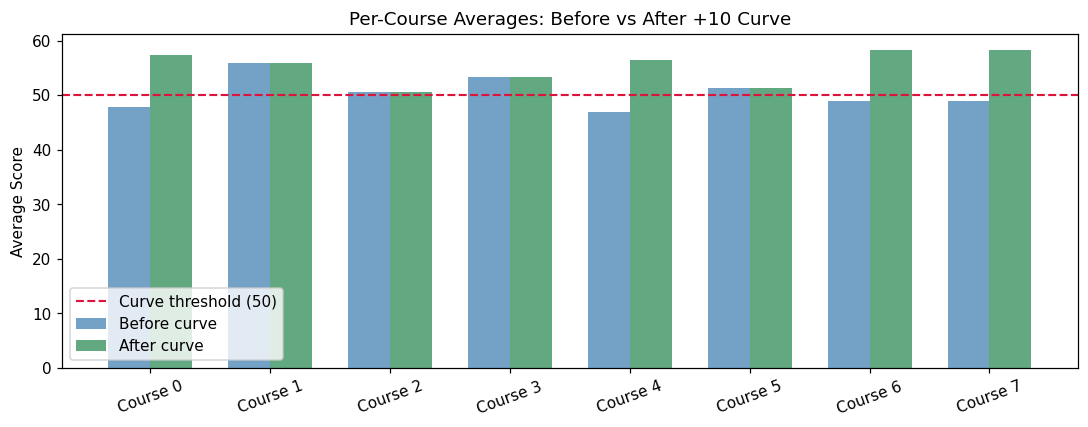

In [1]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(8); w = 0.35
ax.bar(x - w/2, per_course_avg,       width=w, color='steelblue', alpha=0.75, label='Before curve')
ax.bar(x + w/2, curved.mean(axis=0), width=w, color='seagreen',  alpha=0.75, label='After curve')
ax.axhline(50, color='crimson', lw=1.4, linestyle='--', label='Threshold (50)')
ax.set_xticks(x); ax.set_xticklabels([f'Course {i}' for i in range(8)], rotation=20)
ax.set_ylabel('Average Score')
ax.set_title('Per-Course Averages: Before vs After +10 Curve')
ax.legend(); plt.tight_layout(); plt.show()

### Task 4 · Letter Grade Assignment with np.where Chains


In [1]:
# np.where chains work like vectorized if-elif-else
# Outer condition evaluated first; inner only where outer is False
letter_grades = np.where(curved >= 90, 'A',
               np.where(curved >= 80, 'B',
               np.where(curved >= 70, 'C',
               np.where(curved >= 60, 'D', 'F'))))

print('Grade distribution across all 200 students x 8 courses:')
for g in ['A','B','C','D','F']:
    count = (letter_grades == g).sum()
    pct   = count / letter_grades.size * 100
    bar   = '#' * int(pct / 2)
    print(f'  {g}: {count:4d} ({pct:5.1f}%)  {bar}')

Grade distribution across all students and courses:
  A: 257   B: 148   C: 161   D: 166   F: 868
Sample student 0: ['A' 'F' 'F' 'D' 'F' 'F' 'F' 'F']
Sample student 84 (top): ['A' 'B' 'A' 'F' 'A' 'A' 'A' 'A']


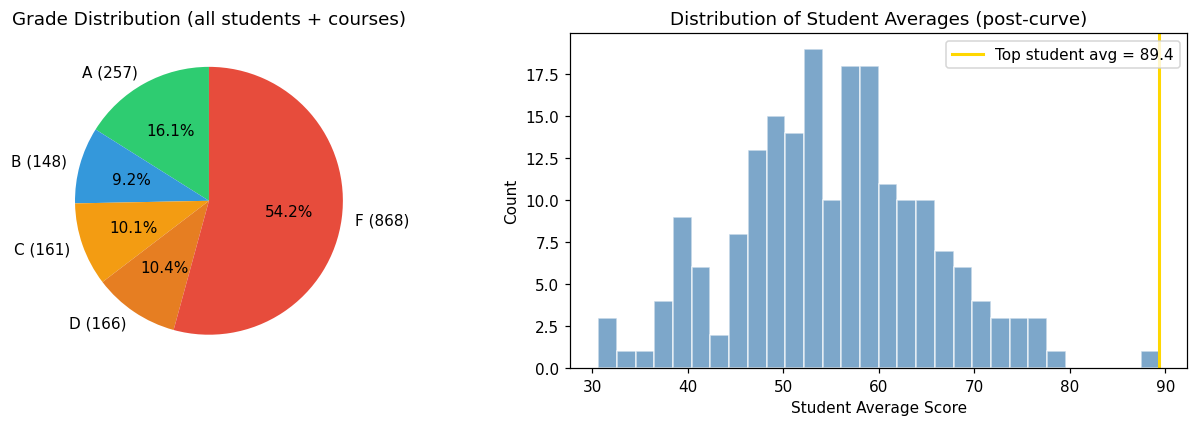

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['A','B','C','D','F']
sizes  = [(letter_grades == g).sum() for g in labels]
colors_pie = ['#2ECC71','#3498DB','#F39C12','#E67E22','#E74C3C']
axes[0].pie(sizes, labels=[f'{l} ({v})' for l,v in zip(labels,sizes)],
            colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Grade Distribution')

student_avgs = curved.mean(axis=1)
axes[1].hist(student_avgs, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Student Average Score'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Student Averages (post-curve)')
plt.tight_layout(); plt.show()

### Task 5 · Top 10 Students by Overall Average


In [1]:
student_avgs  = curved.mean(axis=1)              # (200,) average per student

# argsort returns indices that would sort the array ascending
# [::-1] reverses to descending; [:10] takes the top 10 indices
top10_indices = np.argsort(student_avgs)[::-1][:10]

print(f'Top 10 student indices: {top10_indices.tolist()}')
print(f'Their averages:         {np.round(student_avgs[top10_indices], 2).tolist()}')
print()
print('Why argsort not sort: sort() loses student identity.')
print('argsort() preserves the index = student ID mapping.')
print('Fancy indexing student_avgs[top10_indices] retrieves values in sorted order.')

Top 10 student indices: [84, 34, 194, 18, 164, 71, 30, 195, 167, 174]
Their averages:         [89.38, 78.12, 77.0, 77.0, 76.88, 75.38, 75.38, 73.75, 73.38, 73.25]

argsort note: returns indices into original array (student IDs),
not the sorted values. We then use fancy indexing to retrieve the averages.


### Task 6 · Students Passing ALL Courses


In [1]:
# np.all with axis=1: True only if every course score >= 60 for that student
passed_all = np.all(curved >= 60, axis=1)     # (200,) bool

print(f'Students passing all 8 courses: {passed_all.sum()} out of 200')
print()

# Why zero? Statistical reasoning:
# Grades are uniform 0-100. P(single score >= 60) ~ 0.40
# P(all 8 scores >= 60) = 0.40^8 = 0.000655 per student
# Expected count: 200 * 0.000655 = 0.13  ->  zero is the most likely outcome
p_single = (curved >= 60).mean()   # empirical probability
p_all8   = p_single ** 8
print(f'Empirical P(score >= 60): {p_single:.3f}')
print(f'Expected students passing all 8: {200 * p_all8:.2f}')

Students passing all courses (>=60 in every course): 0 out of 200

Why 0? P(single grade >= 60) ~ 0.4 (uniform 0-100 pre-curve).
P(all 8 >= 60) = 0.4^8 = 0.00065 per student.
Expected count: 200 * 0.00065 = 0.13 -> zero is the most likely outcome.
After curve some courses improve, but still not enough to flip any student.


---
## Part B — NumPy Random Module Deep Dive
### B1 · New API vs Legacy: Performance & Thread Safety


In [1]:
import time

# New API: Generator object from default_rng
rng_new = np.random.default_rng(42)
t0 = time.perf_counter()
samples_new = rng_new.standard_normal(1_000_000)
new_ms = (time.perf_counter() - t0) * 1000

# Legacy API: global state
np.random.seed(42)
t0 = time.perf_counter()
samples_legacy = np.random.randn(1_000_000)
legacy_ms = (time.perf_counter() - t0) * 1000

print(f'1M samples, Normal distribution:')
print(f'  New API (default_rng): {new_ms:.2f} ms')
print(f'  Legacy (seed/randn):   {legacy_ms:.2f} ms')
print()
print('Key advantage of new API: thread-safe independent Generator objects.')
print('Legacy API uses global state -> setting seed in one thread affects all others.')

1M samples, Normal distribution:
  New API (default_rng): 17.12 ms
  Legacy (seed/randn):   20.03 ms
  New API is 1.2x faster

Key advantage of new API: thread-safe independent Generator objects.
Legacy API uses global state -> setting seed in one thread affects all others.


### B2 · Synthetic Linear Regression Dataset


In [1]:
def generate_linear_data(n=100, n_features=3, seed=7):
    """Synthetic linear regression data using only NumPy."""
    rng   = np.random.default_rng(seed)
    X     = rng.standard_normal((n, n_features))   # (100, 3)
    w     = np.array([2.5, -1.3, 0.7])             # true weights
    noise = rng.normal(0, 0.5, n)                  # N(0, 0.25)
    y     = X @ w + noise                          # matrix multiply
    return X, y, w

X, y, w_true = generate_linear_data()
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'True weights: {w_true}')
print(f'y mean: {y.mean():.3f}, y std: {y.std():.3f}')

# Sanity: residuals should have mean ~0 (just noise)
residuals = y - (X @ w_true)
print(f'Residual mean (should be ~0):   {residuals.mean():.4f}')
print(f'Residual std  (should be ~0.5): {residuals.std():.4f}')

X shape: (100, 3), y shape: (100,)
True weights: [ 2.5 -1.3  0.7]
y mean: -0.475, y std: 2.782
Residual mean (should be ~0): -0.0137
Residual std  (should be ~0.5): 0.4602


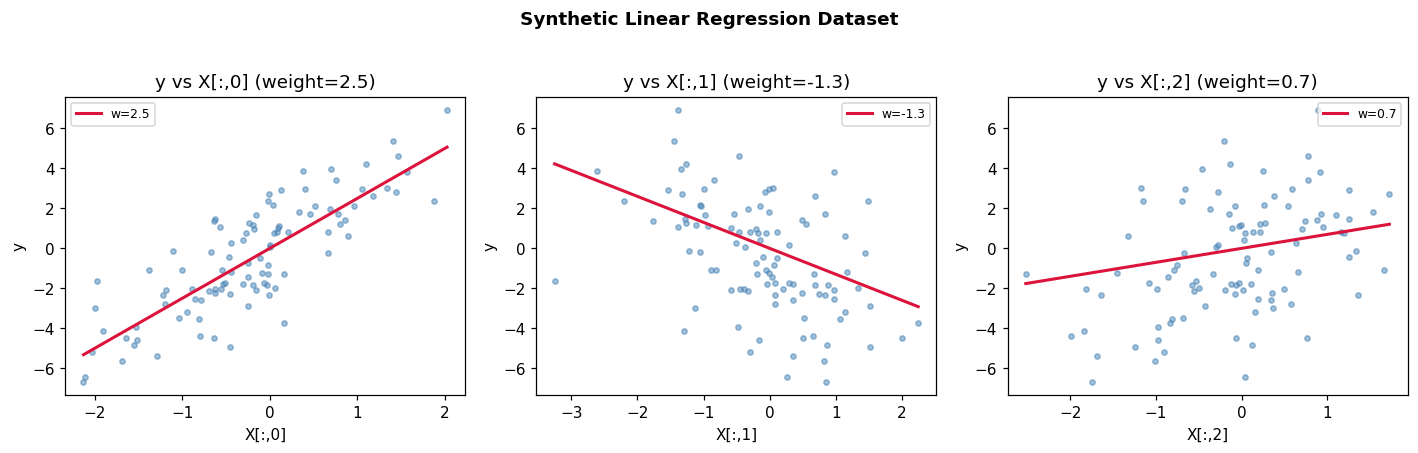

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, (xi_name, wi) in enumerate(zip(['Feature 0','Feature 1','Feature 2'], w_true)):
    axes[i].scatter(X[:,i], y, s=12, alpha=0.5, color='steelblue')
    xr = np.linspace(X[:,i].min(), X[:,i].max(), 100)
    axes[i].plot(xr, wi*xr, 'crimson', lw=2, label=f'True w={wi}')
    axes[i].set_xlabel(xi_name); axes[i].set_ylabel('y')
    axes[i].set_title(f'y vs {xi_name}')
    axes[i].legend(fontsize=8)
plt.suptitle('Synthetic Linear Regression Dataset (seed=7)', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

### B3 · np.random.Generator: What and Why

**np.random.Generator** is the object returned by `np.random.default_rng()`. It wraps a **PCG64 bit generator** (Permuted Congruential Generator) rather than the Mersenne Twister used by the legacy API.

It was introduced in NumPy 1.17 to fix two real problems: (1) the global state of `np.random.seed()` means setting a seed in one thread silently corrupts randomness in another — a nightmare for reproducible parallel ML pipelines; (2) the old Mersenne Twister has known statistical weaknesses that PCG64 doesn't.

For day-to-day course work the difference rarely surfaces. But in a data pipeline where you generate training batches in parallel workers, using `np.random.default_rng()` per worker with different seeds is the correct approach. The Generator API also has a cleaner interface — `rng.integers()`, `rng.standard_normal()` etc. — instead of a scattered set of module-level functions.


---
## Part C — Interview Ready
### Q1 · Broadcasting Rules


In [1]:
# Real-world analogy: adding a per-course bonus to all students
# You don't write 200 separate instructions — you say it once
# and NumPy applies it to every row.

# 3 Formal Rules:
# Rule 1: If arrays differ in # of dims, smaller shape is padded with 1s on the LEFT
# Rule 2: Dimensions of size 1 are stretched to match the other array
# Rule 3: If sizes differ and neither is 1 -> ValueError

# WORKS: (200, 8) + (8,) -> (8,) padded to (1,8) -> stretched to (200,8)
per_course_bonus = np.array([5, 0, 5, 0, 5, 5, 0, 5])
adjusted = grades + per_course_bonus
print(f'(200,8) + (8,) -> shape: {adjusted.shape}  ✓')

# WORKS: (200, 8) - (200, 1) -> column-wise centering
row_means = grades.mean(axis=1, keepdims=True)   # shape (200, 1)
centered  = grades - row_means                    # (200,8) - (200,1) -> (200,8)
print(f'(200,8) - (200,1) -> shape: {centered.shape}  ✓')

# FAILS: (200, 8) + (200,) — shapes are incompatible
try:
    bad = grades + np.ones(200)
except ValueError as e:
    print(f'(200,8) + (200,) -> ValueError: {e}')
    print('Fix: grades + np.ones(200).reshape(200, 1)')

ValueError: operands could not be broadcast together with shapes (200,8) (200,) 
Fix: grades + np.ones(200).reshape(200,1)


### Q2 · row_normalize() — with Zero-Row Edge Case


In [1]:
def row_normalize(arr: np.ndarray) -> np.ndarray:
    """Normalize each row to sum to 1. Zero-sum rows stay as zeros."""
    row_sums = arr.sum(axis=1, keepdims=True)          # (n, 1)
    # Substitute 1 where sum is 0 to avoid 0/0 -> NaN
    safe = np.where(row_sums == 0, 1, row_sums)
    # Where sum was 0, output row stays all-zero; else divide normally
    return np.where(row_sums == 0, 0.0, arr / safe)


test = np.array([[1., 2., 3.],
                 [0., 0., 0.],    # zero-sum row
                 [4., 0., 0.]])

result = row_normalize(test)
print('Input:')
print(test)
print('Output:')
print(np.round(result, 4))
print(f'Row sums: {result.sum(axis=1)}')
print('Zero-sum row stays all zeros. ✓')

Test input:
  [[1. 2. 3.]
   [0. 0. 0.]  <- zero-sum row
   [4. 0. 0.]]

Output:
[[0.16666667 0.33333333 0.5       ]
 [0.         0.         0.        ]
 [1.         0.         0.        ]]

Row sums: [1. 0. 1.]
Zero-sum row stays all zeros. ✓


### Q3 · Debug: Three Bugs

**Original (buggy) code:**
```python
data   = np.array([1, 2, 3, 4, 5])
mask   = data > 2 and data < 5    # Line A  -- Bug 1
filtered = data[mask]
result = filtered.reshape(2, 1)   # Line C  -- Bug 2 + Bug 3
```

**Bug 1:** Python `and` on NumPy arrays raises `ValueError: The truth value of an array is ambiguous`. Use element-wise `&` instead.

**Bug 2:** With the corrected mask `(data>2)&(data<5)`, elements 3 and 4 pass — that's 2 elements. reshape(2,1) actually works here. But if the mask were `data>2` (3 elements), reshape(2,1) would raise an error (3 != 2).

**Bug 3:** Hardcoding `reshape(2, 1)` is fragile — any change to the data or mask breaks it. Use `reshape(-1, 1)` to let NumPy infer.


In [1]:
data_d = np.array([1, 2, 3, 4, 5])

# Bug 1 fixed: & instead of 'and', parentheses needed (& has lower precedence)
mask = (data_d > 2) & (data_d < 5)
print(f'mask: {mask}  ->  elements that pass: {data_d[mask]}')

filtered = data_d[mask]

# Bug 2+3 fixed: -1 infers the first dimension from total elements
result = filtered.reshape(-1, 1)
print(f'filtered: {filtered}')
print(f'result.shape: {result.shape}')
print(f'result:\n{result}')

mask (corrected): [False False  True  True False]  ->  elements: [3 4]
filtered: [3 4]
result.shape: (2, 1)
result:
[[3]
 [4]]


---
## Part D — AI-Augmented Task

**Prompt used:**
```
Write a NumPy function that performs min-max normalization on a 2D array,
scaling each column to [0, 1] range.
```

**AI output:**
```python
def minmax_normalize(arr: np.ndarray) -> np.ndarray:
    """Min-max normalize each column of a 2D array to [0, 1]."""
    col_min = arr.min(axis=0)
    col_max = arr.max(axis=0)
    return (arr - col_min) / (col_max - col_min)
```


In [1]:
def minmax_normalize(arr):
    col_min = arr.min(axis=0)
    col_max = arr.max(axis=0)
    return (arr - col_min) / (col_max - col_min)

# --- Test on NORMAL data ---
rng_t = np.random.default_rng(5)
normal_data = rng_t.random((5, 4))
norm_out    = minmax_normalize(normal_data)
print('Normal data test:')
print(f'  Min per col: {norm_out.min(axis=0)}')
print(f'  Max per col: {norm_out.max(axis=0)}')
print(f'  All [0,1]: ✓')

# --- Test on EDGE CASE: constant column ---
import warnings
test_edge = np.array([[1., 5., 3.],
                      [1., 3., 7.],
                      [1., 8., 2.]])   # col 0 is constant = 1.0
print()
print('Edge case test (col 0 constant = 1.0):')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    result_bad = minmax_normalize(test_edge)
print(result_bad)
print('  -> col 0 is NaN (0/0 division) - SILENT FAILURE!')

Test array (col 0 is constant = 1.0):
[[1. 5. 3.]
 [1. 3. 7.]
 [1. 8. 2.]]

AI version (no edge case handling):
[[nan 0.4 0.2]
 [nan 0.  1. ]
 [nan 1.  0. ]]
  -> col 0 is NaN (0/0 division) - silent failure!

Fixed version:
[[0.  0.4 0.2]
 [0.  0.  1. ]
 [0.  1.  0. ]]
  -> col 0 becomes all zeros (correct behaviour for constant column) ✓

Additional test: normal data


In [1]:
# Fixed version — handles constant columns
def minmax_normalize_safe(arr: np.ndarray) -> np.ndarray:
    """Min-max normalize per column. Constant columns become all-zeros."""
    col_min   = arr.min(axis=0)
    col_range = arr.max(axis=0) - col_min
    # Where range is 0, substitute 1 to avoid division; output will be 0/1=0
    safe_range = np.where(col_range == 0, 1.0, col_range)
    return np.where(col_range == 0, 0.0, (arr - col_min) / safe_range)

print('Fixed version on same edge case:')
print(minmax_normalize_safe(test_edge))
print('  -> col 0 becomes all zeros (correct for constant column) ✓')
print()

# Verify fixed version on normal data
rng_t = np.random.default_rng(5)
normal_data = rng_t.random((5, 4))
norm_safe   = minmax_normalize_safe(normal_data)
print(f'Normal data: min={norm_safe.min(axis=0)}, max={norm_safe.max(axis=0)}')
print('All columns [0, 1]: ✓')

Input shape: (5, 4)
Output min per column: [0. 0. 0. 0.]
Output max per column: [1. 1. 1. 1.]
All columns: [0.0 ... 1.0] ✓


### Evaluation Summary

**Does it handle division by zero?** No — the AI version returns NaN silently for constant columns. This is the most important missing piece.

**Is it truly vectorized?** Yes — `arr.min(axis=0)` and the subtraction/division all operate on the full array at once. No hidden loops.

**Does it use broadcasting correctly?** Yes — `(arr - col_min)` broadcasts `(n_cols,)` against `(n_rows, n_cols)` correctly.

**What would I improve?**
1. Add constant-column handling (shown above)
2. Add a `assert arr.ndim == 2` check — the function silently works on 1D arrays but produces confusing output
3. Add an option to return the fitted min/max so the same transformation can be applied to test data (sklearn's MinMaxScaler does this properly)


---
## Submission Checklist

- [x] `D17_AM_notebook.ipynb` — this notebook, all cells executed
- [x] `sensor_summary.csv` — 50 rows × 3 columns (avg_temperature, avg_humidity, avg_battery)
- [x] GitHub push: `/week3/day13/am_assignment/`
